# 02 — HMM Regime Detection

We explore the use of a regime detection system, namely a Gaussian HMM and use it to extract a signal that could actually have been traded.

**The central issue in this notebook is causality.** Most published HMM regime-detection
code produces signals contaminated by look-ahead bias in two distinct places: smoothed probabilities and training on the entire sample

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys; sys.path.append('..')

from regime_utils import (fit_hmm, sort_states_by_variance, compute_filtered_probs, walk_forward_hmm)

df = pd.read_pickle("data/features.pkl")
features = ["returns", "volatility", "momentum"]
X = df[features].values

## The model

A Hidden Markov Model assumes an unobservable **state** (the regime) that governs the
observable data (returns). Three components:

- **Hidden states** — 2 regimes: calm / stressed
- **Emissions** — a Gaussian per state (`covariance_type="full"` lets returns and
  volatility correlate *within* a state, which they do: the leverage effect)
- **Transition matrix** — states are *sticky*. This persistence is the HMM's main
  advantage over a threshold rule: it models regimes as things that *last*, so it does not
  flip on every noisy observation.

### Initialisation

EM converges to local optima. Multiple random starts, keeping the best log-likelihood,
mitigates this. On the full sample with K=2 all seeds converge identically — but that is a
property of *this* fit, not a general guarantee: on the short rolling windows used later,
initialisation starts to matter.

In [9]:
model, ll = fit_hmm(X, n_states=2, n_inits=10)
order = sort_states_by_variance(model)

print("State means (returns, volatility, momentum):")
print(model.means_[order])
print("\nTransition matrix:")
print(model.transmat_[order][:, order])

A = model.transmat_[order][:, order]
for k, label in enumerate(["Calm", "Stressed"]):
    print(f"{label:9} expected duration: {1/(1-A[k,k]):.0f} trading days")

State means (returns, volatility, momentum):
[[ 0.07686361 10.72539241  2.04107523]
 [-0.03418955 26.29118091 -1.52514681]]

Transition matrix:
[[0.99002665 0.00997335]
 [0.01961412 0.98038588]]
Calm      expected duration: 100 trading days
Stressed  expected duration: 51 trading days


### What the model learned

The two states are economically coherent: the high-volatility state also has a *negative*
mean return and negative momentum — the **leverage effect**, recovered from the data
without being told. Episodes are persistent (months, not days), which is what makes them
regimes rather than noise.

---

## Look-ahead bias, source 1: smoothed vs filtered probabilities

There are three ways to ask "what state am I in?", and conflating them ruins backtests:

| | Conditions on | Causal? |
|---|---|---|
| **Filtered** `P(state_t \| obs_1..t)` | past + present | ✅ **the only tradeable one** |
| **Smoothed** `P(state_t \| obs_1..T)` | the entire sample | ❌ uses the future |
| **Viterbi** (most likely path) | the entire sample | ❌ uses the future |

`hmmlearn`'s `predict_proba()` returns **smoothed**; `predict()` uses **Viterbi**. Neither
is usable as a trading signal.

Concretely: on 15 Feb 2020, filtered only knows what had happened by then — markets were at
all-time highs, so it says "calm". Smoothed has seen March, so it can say "you were already
entering stress". **Smoothed is more accurate because it cheats.**

The forward algorithm computes filtered probabilities. Its recursion only ever touches
`t-1` and `t` — causality by construction.

In [3]:
filtered = compute_filtered_probs(model, X)[:, order]
smoothed = model.predict_proba(X)[:, order]

diff = np.abs(filtered[:, 1] - smoothed[:, 1])
print(f"Mean absolute bias:  {diff.mean():.4f}")
print(f"Max absolute bias:   {diff.max():.4f}")
print(f"99th percentile:     {np.percentile(diff, 99):.4f}")
print(f"Days with bias>0.20: {(diff > 0.20).sum()} of {len(diff)}")

Mean absolute bias:  0.0355
Max absolute bias:   0.8114
99th percentile:     0.6841
Days with bias>0.20: 296 of 4760


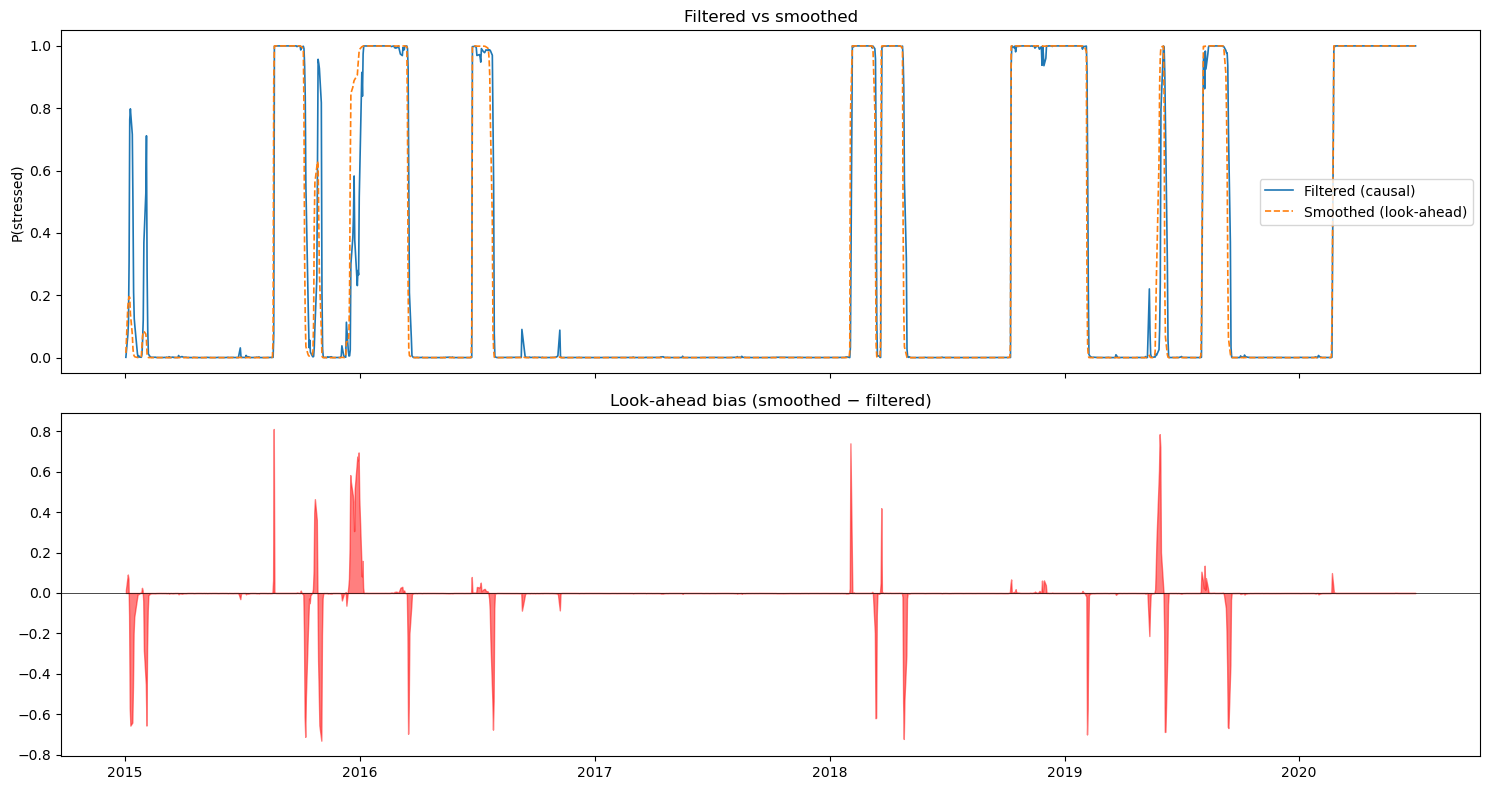

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
mask = (df.index >= "2015-01-01") & (df.index <= "2020-06-30")

axes[0].plot(df.index[mask], filtered[mask, 1], label="Filtered (causal)", lw=1.2)
axes[0].plot(df.index[mask], smoothed[mask, 1], label="Smoothed (look-ahead)", lw=1.2, ls="--")
axes[0].set_ylabel("P(stressed)"); axes[0].legend()
axes[0].set_title("Filtered vs smoothed")

axes[1].fill_between(df.index[mask], 0, smoothed[mask,1] - filtered[mask,1],
                     color="red", alpha=0.5)
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_title("Look-ahead bias (smoothed − filtered)")
plt.tight_layout(); plt.show()

### Reading the bias

The mean bias (~3.5%) **understates the problem**: the bias is near zero during quiet
stretches and spikes to **>80%** at regime transitions — precisely where a strategy makes
its decisions.

Note the spikes go in **both directions**:

- **Positive** — smoothed *anticipates* entry into stress. It knows the crash is coming.
- **Negative** — filtered gets nervous over a scare that turns out to be nothing; smoothed,
  knowing the future, stays calm. **Smoothed silently filters out false positives.**


---

## Look-ahead bias, source 2: the model itself

Filtered probabilities fix the *inference*. But the model above was **fitted on the entire
sample**. Its parameters were estimated having
seen COVID. When it assigns a probability to February 2020, the inference is causal but the
*model* is not.

Closing this requires **walk-forward**: refit periodically on a rolling window of past data
only, then assign forward with the frozen model.

**Design choices:**
- **Rolling (not expanding) window** — markets are non-stationary; a model trained on 2008
  dynamics may not apply today.
- **Monthly refit, not daily** — refitting every day is computationally prohibitive and
  operationally unrealistic; no trader re-estimates every morning.
- **Label switching must be handled.** EM has no commitment to state numbering: "state 0"
  may be calm in one window and stressed in the next. Sorting states by variance anchors
  the labels to an intrinsic property. Without this the signal would invert at random.

In [6]:
probs_wf, diag = walk_forward_hmm(df, features, train_years=4, n_states=2)

np.save("data/probs_hmm_wf.npy", probs_wf)

valid = ~np.isnan(probs_wf[:, 0])
print(f"Days with signal: {valid.sum()} of {len(df)}")
print(f"First signal: {df.index[valid][0].date()}")
print(f"\nTime in stress — in-sample:    {(filtered[valid,1] > 0.5).mean():.1%}")
print(f"Time in stress — walk-forward: {(probs_wf[valid,1] > 0.5).mean():.1%}")
print(f"Mean absolute difference:      {np.abs(filtered[valid,1] - probs_wf[valid,1]).mean():.4f}")

Days with signal: 3736 of 4760
First signal: 2010-03-01

Time in stress — in-sample:    29.6%
Time in stress — walk-forward: 29.7%
Mean absolute difference:      0.1248


### The fitting leak is larger than the smoothing leak

The mean difference between the in-sample and walk-forward signals is **~0.11** — roughly
**three times** the smoothed-vs-filtered bias (~0.035).


---

### Aside: a 3-state model degrades under walk-forward

A K=3 model fitted in-sample produces an appealing structure — calm / normal / crisis, with
near-zero probability of jumping from calm to crisis without passing through normal.

Under walk-forward, however, it breaks down. The *meaning* of the states drifts: the
"crisis" state represents ~17% volatility in 2017 and ~65% in 2021 — the same label for
radically different things. In extended bull markets the training window contains no real
stress, so the model **subdivides noise**; the separation ratio between the highest- and
lowest-volatility states falls below 2.

This is the fundamental cost of the rolling window: **regimes detected by a rolling HMM are
relative to the training window, not absolute.** K=2 is used throughout for robustness.

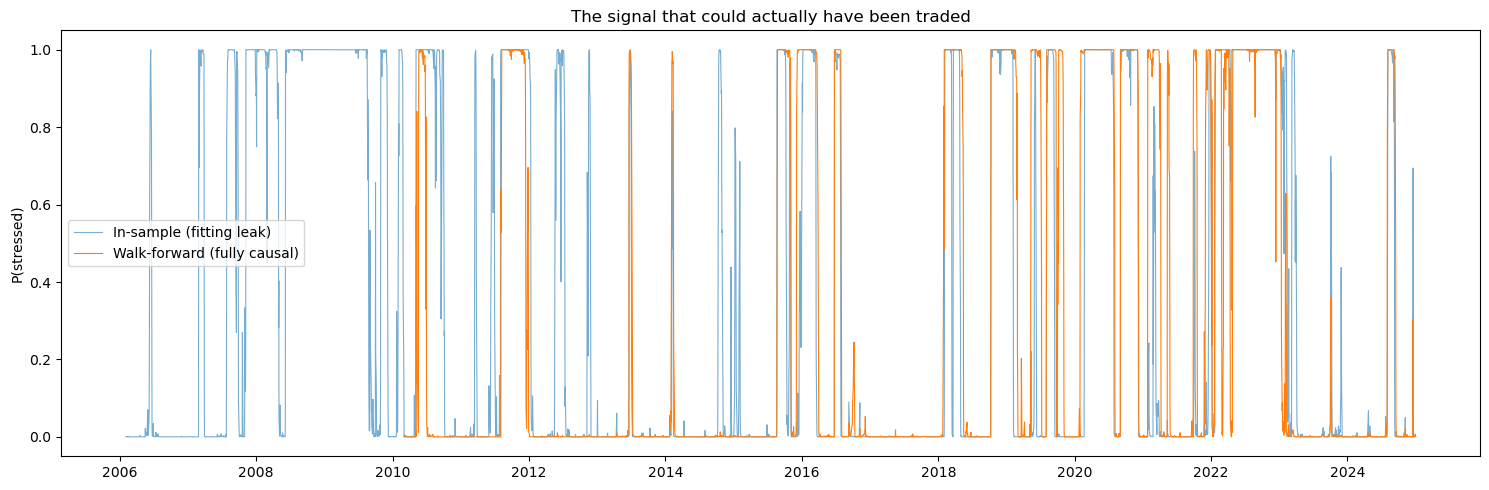

In [7]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df.index, filtered[:, 1], label="In-sample (fitting leak)", lw=0.8, alpha=0.6)
ax.plot(df.index, probs_wf[:, 1], label="Walk-forward (fully causal)", lw=0.8)
ax.set_ylabel("P(stressed)"); ax.legend()
ax.set_title("The signal that could actually have been traded")
plt.tight_layout(); plt.show()